# **Environment Setup**
Menyiapkan pustaka dan konfigurasi awal sebelum data diproses.

In [2]:
import pandas as pd
import numpy as np
import hashlib
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan
pd.set_option("display.max_columns", None)
print("Library siap.")

Library siap.


# **Download Dataset from Kaggle**
Mengunduh dataset versi terbaru dari Kaggle menggunakan pustaka `kagglehub` untuk mendapatkan *raw data* secara otomatis ke dalam direktori kerja.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/credit-card-fraud-detection-dataset-2023")

print("Path to dataset files:", path)

100%|██████████| 143M/143M [00:08<00:00, 17.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/versions/1


# **1). Ambil Data Raw (Data Ingestion)**
Membaca file CSV mentah hasil unduhan dari Kaggle: creditcard_2023.csv. Secara otomatis mendeteksi nilai-nilai kosong seperti "NULL" atau teks kosong agar terbaca sebagai *missing values*.

In [4]:
# Menggabungkan path unduhan dengan nama file
file_name = "creditcard_2023.csv"
full_path = os.path.join(path, file_name)

# Memuat dataset mentah
try:
    df_raw = pd.read_csv(full_path, na_values=["NULL", "null", ""])
    print(f"Dataset Berhasil Dimuat dari: {full_path}")
    print(f"Dimensi Data: {df_raw.shape[0]:,} baris & {df_raw.shape[1]} kolom")
    display(df_raw.head())
except FileNotFoundError:
    print(f"File tidak ditemukan di {full_path}. Cek apakah nama file sudah benar.")

Dataset Berhasil Dimuat dari: /root/.cache/kagglehub/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/versions/1/creditcard_2023.csv
Dimensi Data: 568,630 baris & 31 kolom


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,-0.987020,0.293438,-0.941386,0.549020,1.804879,0.215598,0.512307,0.333644,0.124270,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,0.140107,1.564246,0.574074,0.627719,0.706121,0.789188,0.403810,0.201799,-0.340687,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,-0.272985,0.659201,0.805173,0.616874,3.069025,-0.577514,0.886526,0.239442,-2.366079,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,-0.752581,0.737483,0.592994,0.559535,-0.697664,-0.030669,0.242629,2.178616,-1.345060,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,-1.203171,1.029577,1.439310,0.241454,0.153008,0.224538,0.366466,0.291782,0.445317,0.247237,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


# **2). Audit Kualitas Data (Data Quality Check)**
Tahap pemeriksaan kesehatan data untuk mengidentifikasi masalah seperti duplikasi, data hilang, atau anomali angka.

In [24]:
# Cek Missing Values
missing_stats = df_raw.isnull().sum()
print("[Quality Check] Missing Values:")
print(missing_stats[missing_stats > 0] if missing_stats.sum() > 0 else "Tidak ada data kosong\n")

# Deteksi baris duplikat
duplicate_count = df_raw.duplicated().sum()
print(f"[Quality Check] Baris Duplikat: {duplicate_count} \n")

# Analisis statistik kolom Amount
print("[Quality Check] Deskripsi Statistik Kolom Amount:")
display(df_raw['Amount'].describe())

[Quality Check] Missing Values:
Tidak ada data kosong

[Quality Check] Baris Duplikat: 0 

[Quality Check] Deskripsi Statistik Kolom Amount:


,Amount
count,568630.000000
mean,12041.957635
std,6919.644449
min,50.010000
25%,6054.892500
50%,12030.150000
75%,18036.330000
max,24039.930000


# **3). Data Cleansing & Filtering**
Aturan cleansing yang digunakan:
- Menghapus baris duplikat penuh untuk menjaga integritas data.
- Melakukan filtrasi pada kolom Amount untuk membuang transaksi bernilai negatif.
- Memastikan hanya data dengan logika bisnis yang konsisten yang masuk ke tahap analisis.

In [11]:
# Standarisasi Format Kolom
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Penanganan Missing Values (Data Cleansing)
df = df.dropna(subset=['amount', 'class'])

# Penghapusan Duplikat (Deduplication)
before_rows = len(df)
df = df.drop_duplicates().copy()
after_dedup_rows = len(df)

# Filtering Berdasarkan Logika Bisnis (Data Filtering)
df_clean = df[df["amount"] > 0].copy()

# Menampilkan Ringkasan Proses
print(f"Rows sebelum dedup    : {before_rows:,}")
print(f"Rows sesudah dedup    : {after_dedup_rows:,}")
print(f"Rows sesudah filtering: {len(df_clean):,}")

# Menampilkan sampel data yang sudah bersih
display(df_clean.head())

Rows sebelum dedup    : 568,630
Rows sesudah dedup    : 568,630
Rows sesudah filtering: 568,630


,id,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,-0.987020,0.293438,-0.941386,0.549020,1.804879,0.215598,0.512307,0.333644,0.124270,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,0.140107,1.564246,0.574074,0.627719,0.706121,0.789188,0.403810,0.201799,-0.340687,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,-0.272985,0.659201,0.805173,0.616874,3.069025,-0.577514,0.886526,0.239442,-2.366079,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,-0.752581,0.737483,0.592994,0.559535,-0.697664,-0.030669,0.242629,2.178616,-1.345060,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,-1.203171,1.029577,1.439310,0.241454,0.153008,0.224538,0.366466,0.291782,0.445317,0.247237,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


# **4). GOVERNANCE : Masking Data Sensitif**
Contoh masking yang diterapkan:
- id nasabah di-hash menggunakan algoritme SHA-256 (pseudonymization).
- Kolom identitas asli dihapus untuk menjamin keamanan data pribadi (Data Privacy).

In [12]:
# Menghapus duplikat dan memastikan nominal transaksi valid
df_silver = df_raw.drop_duplicates().copy()
df_silver = df_silver[df_silver['Amount'] >= 0]

# DATA GOVERNANCE: DEFINISI FUNGSI PROTEKSI
def hash_value(value, prefix="id"):
    if pd.isna(value):
        return np.nan
    # Membuat digest SHA-256 dan mengambil 10 karakter pertama
    digest = hashlib.sha256(str(value).encode("utf-8")).hexdigest()[:10]
    return f"{prefix}_{digest}"

# PENERAPAN MASKING & HASHING
df_silver["user_id_hashed"] = df_silver["id"].apply(lambda x: hash_value(x, prefix="user"))

# Menghapus kolom identitas asli untuk mematuhi prinsip privasi data
df_silver = df_silver.drop(columns=["id"])

print(f"Pembersihan Selesai: {len(df_raw) - len(df_silver)} baris dihapus.")
print("Data Governance Selesai: Kolom sensitif telah di-hash.")
display(df_silver[["user_id_hashed", "Amount", "Class"]].head())

Pembersihan Selesai: 0 baris dihapus.
Data Governance Selesai: Kolom sensitif telah di-hash.


,user_id_hashed,Amount,Class
0,user_5feceb66ff,17982.10,0
1,user_6b86b273ff,6531.37,0
2,user_d4735e3a26,2513.54,0
3,user_4e07408562,5384.44,0
4,user_4b227777d4,14278.97,0


# **5). Metadata (Data Dictionary)**
Membuat data dictionary otomatis yang mencakup nama kolom, tipe data, jumlah nilai kosong, persentase data kosong, jumlah nilai unik, serta deskripsi fungsional setiap fitur.

In [13]:
# Definisi deskripsi manual untuk setiap kolom dalam dataset Fraud Detection
column_descriptions = {
    "id": "ID unik transaksi (Original)",
    "V1": "Fitur anonim hasil transformasi PCA (Komponen 1)",
    "V2": "Fitur anonim hasil transformasi PCA (Komponen 2)",
    "V3": "Fitur anonim hasil transformasi PCA (Komponen 3)",
    "V4": "Fitur anonim hasil transformasi PCA (Komponen 4)",
    "V5": "Fitur anonim hasil transformasi PCA (Komponen 5)",
    "V6": "Fitur anonim hasil transformasi PCA (Komponen 6)",
    "V7": "Fitur anonim hasil transformasi PCA (Komponen 7)",
    "V8": "Fitur anonim hasil transformasi PCA (Komponen 8)",
    "V9": "Fitur anonim hasil transformasi PCA (Komponen 9)",
    "V10": "Fitur anonim hasil transformasi PCA (Komponen 10)",
    "V11": "Fitur anonim hasil transformasi PCA (Komponen 11)",
    "V12": "Fitur anonim hasil transformasi PCA (Komponen 12)",
    "V13": "Fitur anonim hasil transformasi PCA (Komponen 13)",
    "V14": "Fitur anonim hasil transformasi PCA (Komponen 14)",
    "V15": "Fitur anonim hasil transformasi PCA (Komponen 15)",
    "V16": "Fitur anonim hasil transformasi PCA (Komponen 16)",
    "V17": "Fitur anonim hasil transformasi PCA (Komponen 17)",
    "V18": "Fitur anonim hasil transformasi PCA (Komponen 18)",
    "V19": "Fitur anonim hasil transformasi PCA (Komponen 19)",
    "V20": "Fitur anonim hasil transformasi PCA (Komponen 20)",
    "V21": "Fitur anonim hasil transformasi PCA (Komponen 21)",
    "V22": "Fitur anonim hasil transformasi PCA (Komponen 22)",
    "V23": "Fitur anonim hasil transformasi PCA (Komponen 23)",
    "V24": "Fitur anonim hasil transformasi PCA (Komponen 24)",
    "V25": "Fitur anonim hasil transformasi PCA (Komponen 25)",
    "V26": "Fitur anonim hasil transformasi PCA (Komponen 26)",
    "V27": "Fitur anonim hasil transformasi PCA (Komponen 27)",
    "V28": "Fitur anonim hasil transformasi PCA (Komponen 28)",
    "Amount": "Nominal transaksi dalam unit mata uang tertentu",
    "Class": "Status transaksi (1 = Fraud/Penipuan, 0 = Normal)",
    "user_id_hashed": "ID unik pengguna yang telah disamarkan dengan SHA-256"
}

# Ekstraksi metadata otomatis dari DataFrame df_silver
dictionary_df = pd.DataFrame({
    "column_name": df_silver.columns,
    "dtype": [str(df_silver[c].dtype) for c in df_silver.columns],
    "null_count": [int(df_silver[c].isna().sum()) for c in df_silver.columns],
    "null_pct": [round(float(df_silver[c].isna().mean() * 100), 2) for c in df_silver.columns],
    "n_unique": [int(df_silver[c].nunique(dropna=True)) for c in df_silver.columns],
    "description": [column_descriptions.get(c, "Deskripsi belum ditambahkan") for c in df_silver.columns]
})

# Menampilkan hasil dokumentasi metadata
print("Data Dictionary - Credit Card Fraud Detection 2023")
display(dictionary_df)

Data Dictionary - Credit Card Fraud Detection 2023


,column_name,dtype,null_count,null_pct,n_unique,description
0,V1,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 1)
1,V2,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 2)
2,V3,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 3)
3,V4,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 4)
4,V5,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 5)
5,V6,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 6)
6,V7,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 7)
7,V8,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 8)
8,V9,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 9)
9,V10,float64,0,0.0,552035,Fitur anonim hasil transformasi PCA (Komponen 10)


# **6). Export Output ke CSV dan Excel**
Output yang dihasilkan:
- credit_card_fraud_clean.csv
- credit_card_fraud_governed.csv
- fraud_data_dictionary.csv
- Credit_Card_Fraud_Full_Report.xlsx (multi-sheet: cleaned_data, governed_data, data_dictionary, business_summary).

In [16]:
# Menyiapkan jalur penyimpanan (Path Management)
clean_csv = "credit_card_fraud_clean.csv"
governed_csv = "credit_card_fraud_governed.csv"
dictionary_csv = "fraud_data_dictionary.csv"
excel_path = "Credit_Card_Fraud_Full_Report.xlsx"

# Ekspor ke format CSV (Individual Files)
df_silver.to_csv(clean_csv, index=False)
df_silver.to_csv(governed_csv, index=False)
dictionary_df.to_csv(dictionary_csv, index=False)

# Ekspor ke format Excel (Multi-Sheet Report)
try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        # Mengambil sampel 10.000 baris untuk sheet Excel
        df_silver.sample(10000, random_state=42).to_excel(writer, index=False, sheet_name="cleaned_data")
        df_silver.sample(10000, random_state=42).to_excel(writer, index=False, sheet_name="governed_data")
        dictionary_df.to_excel(writer, index=False, sheet_name="data_dictionary")

        # Menyimpan ringkasan statistik Class (Normal vs Fraud)
        fraud_summary = df_silver.groupby('Class')['Amount'].agg(['count', 'mean']).reset_index()
        fraud_summary.to_excel(writer, index=False, sheet_name="business_summary")

    excel_status = "Ekspor Excel berhasil"
except Exception as exc:
    excel_status = f"Ekspor Excel gagal: {exc}"

# Menampilkan konfirmasi hasil ekspor
print("Hasil Ekspor Proyek:")
print(f"- CSV Clean: {clean_csv}")
print(f"- CSV Governed: {governed_csv}")
print(f"- CSV Data Dictionary: {dictionary_csv}")
print(f"- Excel Report: {excel_path}")
print(f"Status: {excel_status}")

Hasil Ekspor Proyek:
- CSV Clean: credit_card_fraud_clean.csv
- CSV Governed: credit_card_fraud_governed.csv
- CSV Data Dictionary: fraud_data_dictionary.csv
- Excel Report: Credit_Card_Fraud_Full_Report.xlsx
Status: Ekspor Excel berhasil


# **7). Analisis Dasar & Visualisasi**
Visualisasi : Menghitung rasio penipuan dan tren nominal transaksi untuk memberikan gambaran performa deteksi.

Tabel Rasio Transaksi (%):


,Class,Percentage
0,0,50.0
1,1,50.0


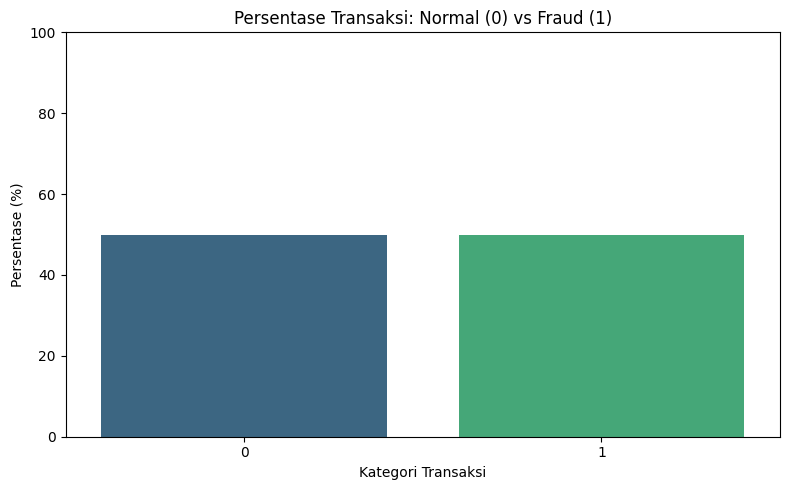


Rata-rata Nominal Transaksi per Kelas:


,Class,Average_Amount
0,0,12026.31
1,1,12057.60


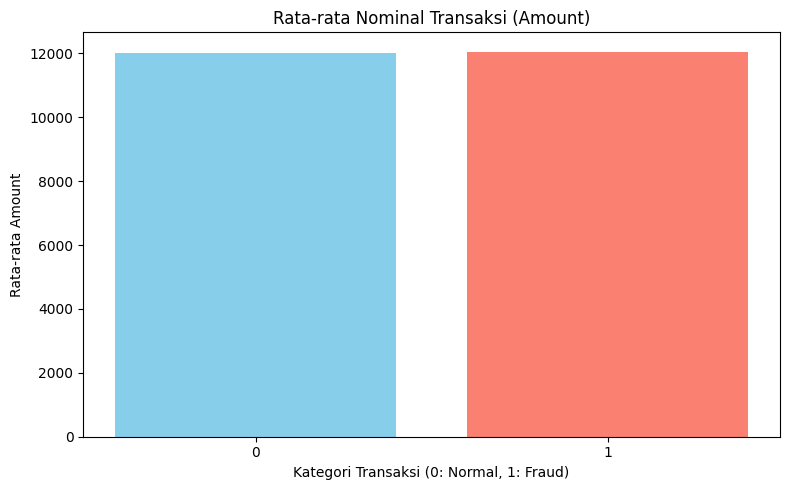

In [21]:
# Agregasi: Menghitung Rasio Transaksi Fraud vs Normal
fraud_rate = df_silver['Class'].value_counts(normalize=True).reset_index()
fraud_rate.columns = ['Class', 'Percentage']
fraud_rate['Percentage'] = (fraud_rate['Percentage'] * 100).round(2)

print("Tabel Rasio Transaksi (%):")
display(fraud_rate)

# Bar Chart Distribusi Transaksi
plt.figure(figsize=(8, 5))
sns.barplot(x='Class', y='Percentage', data=fraud_rate, hue='Class', palette='viridis', legend=False)
plt.title("Persentase Transaksi: Normal (0) vs Fraud (1)")
plt.xlabel("Kategori Transaksi")
plt.ylabel("Persentase (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

amount_analysis = df_silver.groupby("Class", as_index=False)["Amount"].mean().rename(columns={"Amount": "Average_Amount"})
amount_analysis['Average_Amount'] = amount_analysis['Average_Amount'].round(2)

print("\nRata-rata Nominal Transaksi per Kelas:")
display(amount_analysis)

# Bar Chart Rata-rata Nominal
plt.figure(figsize=(8, 5))
plt.bar(amount_analysis["Class"].astype(str), amount_analysis["Average_Amount"], color=['skyblue', 'salmon'])
plt.title("Rata-rata Nominal Transaksi (Amount)")
plt.xlabel("Kategori Transaksi (0: Normal, 1: Fraud)")
plt.ylabel("Rata-rata Amount")
plt.tight_layout()
plt.show()

# **Ringkasan Akhir**
- Dataset telah melalui proses audit kualitas, penghapusan baris duplikat, serta filtrasi anomali pada nominal transaksi.
- Perlindungan privasi diterapkan melalui teknik hashing SHA-256 pada kolom identitas sensitif nasabah.
- Data dictionary disusun secara otomatis untuk memberikan penjelasan teknis dan fungsional pada setiap fitur.
- Agregasi data berhasil menyajikan rasio perbandingan transaksi normal vs penipuan serta tren nilai transaksi.
- Hasil akhir sukses diekspor ke dalam format CSV individu dan laporan Excel multi-sheet yang terorganisir.